In [1]:
import pandas as pd
import requests 
import json
import os
import networkx as nx

import matplotlib.pyplot as plt
#from wordcloud import WordCloud

from collections import defaultdict
import spacy
#import Functions as fn
#import seaborn as sns
import numpy as np  

import re

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
nlp = spacy.load("en_core_sci_sm") 

/opt/conda/lib/python3.11/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [4]:
pwd

'/home/eidf128/eidf128/shared/export/juliana/export/juliana'

In [5]:
home_dir = '/home/eidf128/eidf128/shared/export/juliana/export/juliana'

### Functions

##### Clean

In [6]:
def remove_stop_words(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    filtered = [w for w in tokens if w.lower() not in stop_words and w.isalpha()]

    return filtered

In [7]:
def remove_special_characters(text):
    """
    This function removes special characters from the text.
    :param text: text
    :return: text without special characters
    """
    cleaned_string = re.sub(r'[?|$|.|!|@|#|%|^|&|*|(|)|-|_|+|=|;|:|,|<|>|/|{|}|[|]|~|`|\'|\"|\\]',r'', text)

    return cleaned_string


In [8]:
def clean_text(text):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = remove_special_characters(str(text)) or ""
    
    return remove_stop_words(text)

##### Counts

In [93]:
# It counts the number of words in a phrase
def count_words(phrase):
    """
    This function counts the number of words in a phrase.
    :param phrase: text

    :return: the number of words in the phrase
    """
    lenght = 0
    if len(phrase) > 1 and phrase.isspace() == True:
        lenght = 1
    
    else:
        words = phrase.split()
        lenght = len(words)
    
    return lenght

In [10]:
# It counts the number of characters in a phrase
def count_characters(phrase):
    """
    This function counts the number of characters in a phrase.
    :param phrase: text

    :return: the number of characters in the phrase
    """
    lenght = 0
    if len(phrase) < 1:
        lenght = 0
    else:
        lenght = len(phrase)
        
    return lenght

#### NLP

In [11]:
# It lemmizes a text
def lemmatizer(phrase):
    """
    This function lemmatizes a text.
    :param phrase: text

    :return: the lemmatized text
    """
    doc = nlp(phrase)
    lemmatized_tokens = [token.lemma_ for token in doc]
    lemmatized_text = ' '.join(lemmatized_tokens)
    
    return lemmatized_text

In [12]:
# It extracts the entities from a text
def entities_recognition(phrase):
    """
    This function extracts the entities from a text.
    :param phrase: text
    :return: the entities extracted from the text
    """
    entities = []
    doc_phrase = nlp(phrase)
    entities = list(doc_phrase.ents)
    
    return entities

##### Organization

In [13]:
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA

In [14]:
def join_unique_non_null(s, sep=" | "):
    s = s.dropna().astype(str)
    s = s[s.str.strip().ne("")]           # drop empty strings
    s = pd.unique(s)                      # keep unique (preserve order)
    return sep.join(s) if len(s) else pd.NA

### Reading the data and creating df

In [15]:
data_dir = '/home/eidf128/eidf128/shared/export/juliana/export/juliana/items'

In [35]:
os.chdir(data_dir)

In [36]:
json_files = [f for f in os.listdir(data_dir) if f.endswith('.json')]
json_files

['49dbc9e1-eeab-411b-8510-080ceb5dccfa_in_78be837d-99a1-4da9-813d-fa139b2853f2.json',
 'ecfd3009-d585-4b1a-9137-6b7460379b94_in_78be837d-99a1-4da9-813d-fa139b2853f2.json',
 '619bb04f-94c4-4eb8-9511-b2dfeaa3412a_in_78be837d-99a1-4da9-813d-fa139b2853f2.json',
 'e232d2db-1621-47df-bb6d-ea69187de44f_in_3b8e9ad5-7d72-430c-aed5-a73376ba2bf8.json',
 '9bf808da-4a87-4bfc-a885-4f53bf7531fc_in_300bc74f-b2ca-4cdb-94f8-757e57d8f753.json',
 '50e06d54-ef79-4eda-ba70-53af5f601281_in_78be837d-99a1-4da9-813d-fa139b2853f2.json',
 '4e3448ea-fc40-4b5c-94f4-a429349bbc27_in_456eccd4-54f2-48f2-afb0-c4a02936452c.json',
 'c453e153-7b18-4b3d-ae05-69ef3210e4c7_in_9053e53c-3f3e-443a-940a-bf374489f89c.json',
 '2f73dbf5-7b4a-4f18-a29c-20a046031c39_in_78be837d-99a1-4da9-813d-fa139b2853f2.json',
 '35241ba3-5bd0-4266-966f-fbbdedf2d53b_in_78be837d-99a1-4da9-813d-fa139b2853f2.json',
 '687d6803-5d6e-447d-b9ed-d9f71d4a3d26_in_78be837d-99a1-4da9-813d-fa139b2853f2.json',
 'f084fe67-dfb5-4569-b9a1-759ef2ddbdc3_in_51c495e9-9c4

In [37]:
dfs_datashare = []

In [38]:
for json_file in json_files:
    json_1 = open(json_file)
    json_dicc = json.load(json_1)

    file_name = os.path.basename(json_file)
    
    result = defaultdict(list)

    for item in json_dicc:
        key = item['key']
        value = item['value']
        result[key].append(value)

    result_dict = dict(result)

    df = pd.json_normalize(result_dict)
    name = file_name.split('_')[0]
    collection = file_name.split('_')[2]
    df['file_name'] = file_name
    df['collection'] = collection.split('.')[0]
    df['id_in_file'] = name

    dfs_datashare.append(df)

df_datashare_collapse = pd.concat(dfs_datashare)

In [39]:
df_datashare_collapse.columns

Index(['dc.contributor', 'dc.contributor.other', 'dc.coverage.spatial',
       'dc.coverage.temporal', 'dc.creator', 'dc.date.accessioned',
       'dc.date.available', 'dc.identifier.citation', 'dc.identifier.uri',
       'dc.description.abstract', 'dc.language.iso', 'dc.publisher',
       'dc.relation.isreferencedby', 'dc.rights', 'dc.subject',
       'dc.subject.classification', 'dc.title', 'dc.type', 'file_name',
       'collection', 'id_in_file', 'dc.relation.isversionof',
       'dc.description.tableofcontents', 'dc.source', 'dc.title.alternative',
       'dc.relation.isreplacedby', 'dc.date.updated', 'dc.date.embargo',
       'dc.relation.replaces', 'dc.source.uri', 'dc.date.issued',
       'dcterms.subject', 'dcterms.isReferencedBy', 'dc.contributor.advisor',
       'dc.relation.hasversion', 'dc.contributor.author', 'dc.description',
       'dc.description.sponsorship', 'dc.relation.ispartofseries',
       'ds.withdrawn.showtombstone', 'dc.relation.isbasedon', 'dcterms.rights',


### Cleaning

In [40]:
# Replace None with nothing
df_datashare_collapse.replace(to_replace=[None], value="", inplace=True)

,dc.contributor,dc.contributor.other,dc.coverage.spatial,dc.coverage.temporal,dc.creator,dc.date.accessioned,dc.date.available,dc.identifier.citation,dc.identifier.uri,dc.description.abstract,...,dc.contributor.author,dc.description,dc.description.sponsorship,dc.relation.ispartofseries,ds.withdrawn.showtombstone,dc.relation.isbasedon,dcterms.rights,dc.relation.ispartof,dcterms.isReplacedBy,dcterms.publisher
0,"[Glendinning, Miles, Breen, Kat]",[Heritage Lottery Fund],"[Wolverhampton City, United Kingdom]",[start=1987; end=1987; scheme=W3C-DTF],"[Glendinning, Miles]",[2023-05-17T16:00:22Z],[2023-05-17T16:00:22Z],"[Glendinning, Miles. (2023). Tower Blocks UK: ...","[https://hdl.handle.net/10283/8181, https://do...",[Multi-storey block details: two 8-storey bloc...,...,,,,,,,,,,
0,"[Glendinning, Miles, Breen, Kat]",[Heritage Lottery Fund],"[Enfield London, United Kingdom]",[start=1988; end=1988; scheme=W3C-DTF],"[Glendinning, Miles]",[2023-05-17T13:55:10Z],[2023-05-17T13:55:10Z],"[Glendinning, Miles. (2023). Tower Blocks UK: ...","[https://hdl.handle.net/10283/5559, https://do...",[Multi-storey block details: four 12-storey bl...,...,,,,,,,,,,
0,"[Glendinning, Miles, Breen, Kat]",[Heritage Lottery Fund],"[AB11 8TW; AB11 8TX; AB11 8TY, Aberdeen, UK, U...",[start=1983; end=1983; scheme=W3C-DTF],"[Glendinning, Miles]",[2019-11-14T09:55:05Z],[2019-11-14T09:55:05Z],"[Glendinning, Miles. (2019). SC_1141943.png, B...","[https://hdl.handle.net/10283/3445, https://do...",[Multi-storey block details: three 14-storey b...,...,,,,,,,,,,
0,"[Kim, Jinho]",[University of Edinburgh],,,"[Kim, Jinho]",[2017-06-14T11:00:41Z],[2017-06-14T11:00:41Z],"[Kim, Jinho. (2017). Source codes of the netwo...","[https://hdl.handle.net/10283/2737, https://do...",[This data set contains the source codes for t...,...,,,,,,,,,,
0,"[Anjos, Miguel]",[University of Edinburgh],,,"[Burkard, RE, Çela, E, Karisch, SE, Rendl, F, ...",[2022-03-31T16:59:08Z],[2022-03-31T16:59:08Z],"[Burkard, RE; Çela, E; Karisch, SE; Rendl, F; ...","[https://hdl.handle.net/10283/4390, https://do...",[The Quadratic Assignment Problem (QAP) has re...,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,"[Nadal, Cathe Desiree]",[Self-funded],"[Cavite, Cavite, Philippines, PH, PHILIPPINES]",,"[Nadal, Cathe Desire, Del Rosario, Tovie Clart...",[2022-10-11T14:40:23Z],[2022-10-11T14:40:23Z],"[Nadal, Cathe Desire; Del Rosario, Tovie Clart...","[https://hdl.handle.net/10283/4758, https://do...","[""CAPTURING THE DYNAMIC CHARACTER OF THE PHILI...",...,,,,,,,,,,
0,"[Glendinning, Miles, Breen, Kat]",[Heritage Lottery Fund],"[Sefton, United Kingdom]",[start=1987; end=1987; scheme=W3C-DTF],"[Glendinning, Miles]",[2023-05-17T15:43:57Z],[2023-05-17T15:43:57Z],"[Glendinning, Miles. (2023). Tower Blocks UK: ...","[https://hdl.handle.net/10283/7742, https://do...",[Multi-storey block details: one 16-storey blo...,...,,,,,,,,,,
0,"[Glendinning, Miles, Breen, Kat]",[Heritage Lottery Fund],"[Camden London, United Kingdom]",[start=1988; end=1988; scheme=W3C-DTF],"[Glendinning, Miles]",[2023-05-17T13:34:44Z],[2023-05-17T13:34:44Z],"[Glendinning, Miles. (2023). Tower Blocks UK: ...","[https://hdl.handle.net/10283/5355, https://do...",[Multi-storey block details: CS 1: eleven 6-st...,...,,,,,,,,,,
0,"[Glendinning, Miles, Breen, Kat]",[Heritage Lottery Fund],"[Salford City, United Kingdom]",[start=1987; end=1987; scheme=W3C-DTF],"[Glendinning, Miles]",[2023-05-17T15:41:06Z],[2023-05-17T15:41:06Z],"[Glendinning, Miles. (2023). Tower Blocks UK: ...","[https://hdl.handle.net/10283/7619, https://do...",[Multi-storey block details: one 20-storey blo...,...,,,,,,,,,,


In [41]:
# Everything to lowercase
obj_cols = df_datashare_collapse.select_dtypes(include = ["object", "string"]).columns #Select columns that have strings on it
df_datashare_collapse[obj_cols] = df_datashare_collapse[obj_cols].astype("string").apply(lambda s: s.str.lower())

### Stats

In [42]:
df_datashare_collapse.columns

Index(['dc.contributor', 'dc.contributor.other', 'dc.coverage.spatial',
       'dc.coverage.temporal', 'dc.creator', 'dc.date.accessioned',
       'dc.date.available', 'dc.identifier.citation', 'dc.identifier.uri',
       'dc.description.abstract', 'dc.language.iso', 'dc.publisher',
       'dc.relation.isreferencedby', 'dc.rights', 'dc.subject',
       'dc.subject.classification', 'dc.title', 'dc.type', 'file_name',
       'collection', 'id_in_file', 'dc.relation.isversionof',
       'dc.description.tableofcontents', 'dc.source', 'dc.title.alternative',
       'dc.relation.isreplacedby', 'dc.date.updated', 'dc.date.embargo',
       'dc.relation.replaces', 'dc.source.uri', 'dc.date.issued',
       'dcterms.subject', 'dcterms.isReferencedBy', 'dc.contributor.advisor',
       'dc.relation.hasversion', 'dc.contributor.author', 'dc.description',
       'dc.description.sponsorship', 'dc.relation.ispartofseries',
       'ds.withdrawn.showtombstone', 'dc.relation.isbasedon', 'dcterms.rights',


In [43]:
df_datashare_collapse["dc.description.abstract_clean"] = pd.Series(index = df_datashare_collapse.index, dtype="object")

In [44]:
print(df_datashare_collapse.shape)

(7754, 46)


In [45]:
df_datashare_collapse = df_datashare_collapse.reset_index(drop=True)

In [46]:
print(df_datashare_collapse.index)
print(df_datashare_collapse.index.is_unique)
print(df_datashare_collapse.index.value_counts().head())


RangeIndex(start=0, stop=7754, step=1)
True
0    1
1    1
2    1
3    1
4    1
Name: count, dtype: int64


In [47]:
type(df_datashare_collapse)

pandas.DataFrame

In [48]:
df_datashare_collapse

,dc.contributor,dc.contributor.other,dc.coverage.spatial,dc.coverage.temporal,dc.creator,dc.date.accessioned,dc.date.available,dc.identifier.citation,dc.identifier.uri,dc.description.abstract,...,dc.description,dc.description.sponsorship,dc.relation.ispartofseries,ds.withdrawn.showtombstone,dc.relation.isbasedon,dcterms.rights,dc.relation.ispartof,dcterms.isReplacedBy,dcterms.publisher,dc.description.abstract_clean
0,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['wolverhampton city', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t16:00:22z'],['2023-05-17t16:00:22z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/8181', 'https:/...","[""multi-storey block details: two 8-storey blo...",...,,,,,,,,,,NaN
1,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['enfield london', 'united kingdom']",['start=1988; end=1988; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t13:55:10z'],['2023-05-17t13:55:10z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/5559', 'https:/...","[""multi-storey block details: four 12-storey b...",...,,,,,,,,,,NaN
2,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['ab11 8tw; ab11 8tx; ab11 8ty', 'aberdeen', '...",['start=1983; end=1983; scheme=w3c-dtf'],"['glendinning, miles']",['2019-11-14t09:55:05z'],['2019-11-14t09:55:05z'],"['glendinning, miles. (2019). sc_1141943.png, ...","['https://hdl.handle.net/10283/3445', 'https:/...","[""multi-storey block details: three 14-storey ...",...,,,,,,,,,,NaN
3,"['kim, jinho']",['university of edinburgh'],,,"['kim, jinho']",['2017-06-14t11:00:41z'],['2017-06-14t11:00:41z'],"['kim, jinho. (2017). source codes of the netw...","['https://hdl.handle.net/10283/2737', 'https:/...",['this data set contains the source codes for ...,...,,,,,,,,,,NaN
4,"['anjos, miguel']",['university of edinburgh'],,,"['burkard, re', 'çela, e', 'karisch, se', 'ren...",['2022-03-31t16:59:08z'],['2022-03-31t16:59:08z'],"['burkard, re; çela, e; karisch, se; rendl, f;...","['https://hdl.handle.net/10283/4390', 'https:/...",['the quadratic assignment problem (qap) has r...,...,,,,,,,,,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7749,"['nadal, cathe desiree']",['self-funded'],"['cavite', 'cavite, philippines', 'ph', 'phili...",,"['nadal, cathe desire', 'del rosario, tovie cl...",['2022-10-11t14:40:23z'],['2022-10-11t14:40:23z'],"['nadal, cathe desire; del rosario, tovie clar...","['https://hdl.handle.net/10283/4758', 'https:/...","['""capturing the dynamic character of the phil...",...,,,,,,,,,,NaN
7750,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['sefton', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t15:43:57z'],['2023-05-17t15:43:57z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/7742', 'https:/...","[""multi-storey block details: one 16-storey bl...",...,,,,,,,,,,NaN
7751,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['camden london', 'united kingdom']",['start=1988; end=1988; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t13:34:44z'],['2023-05-17t13:34:44z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/5355', 'https:/...","[""multi-storey block details: cs 1: eleven 6-s...",...,,,,,,,,,,NaN
7752,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['salford city', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t15:41:06z'],['2023-05-17t15:41:06z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/7619', 'https:/...","[""multi-storey block details: one 20-storey bl...",...,,,,,,,,,,NaN


In [49]:
#nltk.download('punkt_tab')

In [50]:
df2 = df_datashare_collapse.reset_index(drop=True)
col = "dc.description.abstract"

for i, row in df2.iterrows():
    print(f"Processing row {i+1}/{len(df2)}")

    value_to_clean = row[col]
    if pd.notna(value_to_clean) and value_to_clean != "":
        df2.at[i, "dc.description.abstract_clean"] = clean_text(value_to_clean)

df_datashare_collapse = df2

Processing row 1/7754


LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - '/home/jovyan/nltk_data'
    - '/opt/conda/nltk_data'
    - '/opt/conda/share/nltk_data'
    - '/opt/conda/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
df_datashare_collapse

In [ ]:
list_headers_stats_clean = ["dc.description.abstract_clean"]

In [ ]:
df_datashare_collapse["dc.description.abstract_clean_word_count"] = pd.Series(index = df_datashare_collapse.index, dtype="object")

In [ ]:
# Word count
df_datashare_collapse["dc.description.abstract_clean_word_count"] = (
    df_datashare_collapse["dc.description.abstract_clean"]
      .apply(lambda x: len(x) if isinstance(x, list) else 0)
)

In [ ]:
# Creating the empty columns for lemma text and entities 
for header in list_headers_stats_clean:
    df_datashare_collapse[f"{header}_lemmatize"] = pd.Series(index = df_datashare_collapse.index, dtype="object")
    df_datashare_collapse[f"{header}_entities"]  = pd.Series(index = df_datashare_collapse.index, dtype="object")

In [ ]:
def to_text(x):
    # missing
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    # already a string
    if isinstance(x, str):
        return x
    # list/tuple/set/np array of tokens
    if isinstance(x, (list, tuple, set, np.ndarray)):
        return " ".join(map(str, x))
    # fallback: convert whatever it is to string
    return str(x)


In [ ]:
# Lemmatisation and entity recognition
for idx, row in df_datashare_collapse.iterrows():
    for header in list_headers_stats_clean: 
        
        text = df_datashare_collapse.at[idx, header]
        join_text = to_text(text)
        
        lemma_str = lemmatizer("" if pd.isna(join_text) else str(join_text))
        title_lemma = f"{header}_lemmatize"
        df_datashare_collapse.at[idx, title_lemma] = lemma_str

        entities = entities_recognition(lemma_str)
        title_entities = f"{header}_entities"
        df_datashare_collapse.at[idx, title_entities] = entities

In [ ]:
df_datashare_collapse

### Saving the dataset for future work 

In [ ]:
os.getcwd()

In [ ]:
cd ..

In [ ]:
#df_datashare_collapse.to_csv("df_datashare_collpase_20260311.csv")

### Organize by communities

In [ ]:
pwd

In [ ]:
with open("items_medicine_datashare_oct2024.txt", "r", encoding="utf-8") as f:
    items_medicine = [line.strip() for line in f if line.strip()]  # strips \n and skips blank lines

items_medicine

In [ ]:
with open("items_arts_datashare_oct2024.txt", "r", encoding="utf-8") as f:
    items_arts = [line.strip() for line in f if line.strip()]  # strips \n and skips blank lines

items_arts

In [ ]:
with open("items_sciences_datashare_oct2024.txt", "r", encoding="utf-8") as f:
    items_science = [line.strip() for line in f if line.strip()]  # strips \n and skips blank lines

items_science

In [ ]:
with open("items_thematic_datashare_oct2024.txt", "r", encoding="utf-8") as f:
    items_thematic = [line.strip() for line in f if line.strip()]  # strips \n and skips blank lines

items_thematic

In [ ]:
with open("items_support_datashare_oct2024.txt", "r", encoding="utf-8") as f:
    items_support = [line.strip() for line in f if line.strip()]  # strips \n and skips blank lines

items_support

In [ ]:
df_datashare_collapse.columns

In [ ]:
df_datashare_collapse["id_in_file"]

In [ ]:
df_medicine = df_datashare_collapse[df_datashare_collapse["id_in_file"].isin(items_medicine)].copy()

In [ ]:
df_arts = df_datashare_collapse[df_datashare_collapse["id_in_file"].isin(items_arts)].copy()

In [ ]:
df_science = df_datashare_collapse[df_datashare_collapse["id_in_file"].isin(items_science)].copy()

In [ ]:
df_support = df_datashare_collapse[df_datashare_collapse["id_in_file"].isin(items_support)].copy()

In [ ]:
df_thematic = df_datashare_collapse[df_datashare_collapse["id_in_file"].isin(items_thematic)].copy()

#### Saving the files

In [ ]:
#df_medicine.to_csv("df_medicine_datashare_collpase_20260401.csv")

In [ ]:
#df_arts.to_csv("df_arts_datashare_collpase_20260401.csv")

In [ ]:
#df_science.to_csv("df_science_datashare_collpase_20260401.csv")

In [ ]:
#df_support.to_csv("df_support_datashare_collpase_20260401.csv")

In [ ]:
#df_thematic.to_csv("df_thematic_collpase_20260401.csv")

### ANOVA calculation

In [6]:
df_datashare = pd.read_csv("df_datashare_collpase_20260311.csv")

In [7]:
df_datashare["id_in_file"]

0       49dbc9e1-eeab-411b-8510-080ceb5dccfa
1       ecfd3009-d585-4b1a-9137-6b7460379b94
2       619bb04f-94c4-4eb8-9511-b2dfeaa3412a
3       e232d2db-1621-47df-bb6d-ea69187de44f
4       9bf808da-4a87-4bfc-a885-4f53bf7531fc
                        ...                 
7749    95b48a67-d9d6-497b-92f8-eca8ba9eb13e
7750    5a681507-5f98-4b33-821a-f7a14e27e6e7
7751    f5a80a20-a794-45e8-8f67-de9031a43037
7752    163fe91b-f71a-4337-9baf-8bfe1ddbb9ae
7753    2a18550b-fdaa-47a4-94a2-5359ae0266a3
Name: id_in_file, Length: 7754, dtype: str

In [8]:
df_medicine = pd.read_csv("df_medicine_datashare_collpase_20260401.csv")
df_science = pd.read_csv("df_science_datashare_collpase_20260401.csv")
df_arts = pd.read_csv("df_arts_datashare_collpase_20260401.csv")
df_support = pd.read_csv("df_support_datashare_collpase_20260401.csv")
df_thematic = pd.read_csv("df_thematic_datashare_collpase_20260401.csv")

In [9]:
df_medicine["id_in_file"]

0       4e3448ea-fc40-4b5c-94f4-a429349bbc27
1       f084fe67-dfb5-4569-b9a1-759ef2ddbdc3
2       cd2050a6-2b6c-4f95-909e-e5abf6f9dcde
3       d27ec461-8149-4b76-bad5-a7fe5c1ee06d
4       cf8c904b-ce8d-4688-b0cb-5bdbfbd337b8
                        ...                 
1701    14f0cc2d-ca78-4eae-a2d7-5e6ae3f0f047
1702    92c56b5b-faf3-4eb4-8605-09058ab93e90
1703    aa83b9a5-ece6-4b21-a7d5-8d44fd1c89c3
1704    fefaa869-373d-4b8f-9519-08227a263606
1705    15bd05df-57f0-4043-9980-70022ef5ec73
Name: id_in_file, Length: 1706, dtype: str

### Matching dataframes

In [10]:
df_datashare["id_in_file"] = df_datashare["id_in_file"].astype(str)

df_medicine["id_in_file"] = df_medicine["id_in_file"].astype(str)
df_science["id_in_file"] = df_science["id_in_file"].astype(str)
df_arts["id_in_file"] = df_arts["id_in_file"].astype(str)
df_support["id_in_file"] = df_support["id_in_file"].astype(str)
df_thematic["id_in_file"] = df_thematic["id_in_file"].astype(str)

In [11]:
import numpy as np

conditions = [
    df_datashare["id_in_file"].isin(df_medicine["id_in_file"]),
    df_datashare["id_in_file"].isin(df_science["id_in_file"]),
    df_datashare["id_in_file"].isin(df_arts["id_in_file"]),
    df_datashare["id_in_file"].isin(df_support["id_in_file"]),
    df_datashare["id_in_file"].isin(df_thematic["id_in_file"]),
]

choices = ["Medicine", "Science", "Arts", "Support", "Thematic"]

df_datashare["community"] = np.select(conditions, choices, default="No match")


In [12]:
count = 0
for idx, row in df_datashare.iterrows():
    if df_datashare.at[idx,"community"] == "No match":
        count +=1
print(count)

422


In [57]:
df_datashare

,Unnamed: 0,dc.contributor,dc.contributor.other,dc.coverage.spatial,dc.coverage.temporal,dc.creator,dc.date.accessioned,dc.date.available,dc.identifier.citation,dc.identifier.uri,...,dc.description.abstract_clean_entities,community,entities,entities_counter,entities_count,unique_entities_count,dc.description.abstract_clean_entities_white_spaces,ratio_entities_per_word,ratio_bin,ratio_entities_per_word_with_spaces
0,0,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['wolverhampton city', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t16:00:22z'],['2023-05-17t16:00:22z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/8181', 'https:/...",...,"[block, block, block, wulfruna, wulfruna, gran...",Arts,"[[block, block, block, wulfruna, wulfruna,...","{'[block': 1, ' block': 2, ' wulfruna': 2, ' g...",42,34,"[[block,, block,, block,, wulfruna,, wulfruna,...",0.281879,"(0.4, 0.5]",0.402685
1,1,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['enfield london', 'united kingdom']",['start=1988; end=1988; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t13:55:10z'],['2023-05-17t13:55:10z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/5559', 'https:/...",...,"[block, block, block, picardy house normandy h...",Arts,"[[block, block, block, picardy house norman...","{'[block': 1, ' block': 3, ' picardy house nor...",43,35,"[[block,, block,, block,, picardy, house, norm...",0.281046,"(0.4, 0.5]",0.457516
2,2,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['ab11 8tw; ab11 8tx; ab11 8ty', 'aberdeen', '...",['start=1983; end=1983; scheme=w3c-dtf'],"['glendinning, miles']",['2019-11-14t09:55:05z'],['2019-11-14t09:55:05z'],"['glendinning, miles. (2019). sc_1141943.png, ...","['https://hdl.handle.net/10283/3445', 'https:/...",...,"[block detail, block, block, grampian, image, ...",Arts,"[[block detail, block, block, grampian, im...","{'[block detail': 1, ' block': 2, ' grampian':...",42,33,"[[block, detail,, block,, block,, grampian,, i...",0.287671,"(0.4, 0.5]",0.417808
3,3,"['kim, jinho']",['university of edinburgh'],NaN,NaN,"['kim, jinho']",['2017-06-14t11:00:41z'],['2017-06-14t11:00:41z'],"['kim, jinho. (2017). source codes of the netw...","['https://hdl.handle.net/10283/2737', 'https:/...",...,"[code simulation, thompson centralized random ...",Science,"[[code simulation, thompson centralized rando...","{'[code simulation': 1, ' thompson centralized...",6,6,"[[code, simulation,, thompson, centralized, ra...",0.260870,"(0.4, 0.5]",0.478261
4,4,"['anjos, miguel']",['university of edinburgh'],NaN,NaN,"['burkard, re', 'çela, e', 'karisch, se', 'ren...",['2022-03-31t16:59:08z'],['2022-03-31t16:59:08z'],"['burkard, re; çela, e; karisch, se; rendl, f;...","['https://hdl.handle.net/10283/4390', 'https:/...",...,"[quadratic assignment problem qap, combinatori...",Science,"[[quadratic assignment problem qap, combinato...","{'[quadratic assignment problem qap': 1, ' com...",13,13,"[[quadratic, assignment, problem, qap,, combin...",0.333333,"(0.5, 0.6]",0.512821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7749,7749,"['nadal, cathe desiree']",['self-funded'],"['cavite', 'cavite, philippines', 'ph', 'phili...",NaN,"['nadal, cathe desire', 'del rosario, tovie cl...",['2022-10-11t14:40:23z'],['2022-10-11t14:40:23z'],"['nadal, cathe desire; del rosario, tovie clar...","['https://hdl.handle.net/10283/4758', 'https:/...",...,"[dynamic, landscape, landscape, cavite, landsc...",No match,"[[dynamic, landscape, landscape, cavite, l...","{'[dynamic': 1, ' landscape': 6, ' cavite': 2,...",20,12,"[[dynamic,, landscape,, landscape,, cavite,, l...",0.408163,"(0.4, 0.5]",0.428571
7750,7750,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['sefton', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']

#### Global counts

In [14]:
from collections import Counter

In [15]:
df_datashare["entities_count"] = ""

In [16]:
df_datashare["entities_count"] = df_datashare["dc.description.abstract_clean_entities"].apply(lambda x: len(x) if isinstance(x, str) else 0)

In [94]:
count_words(df_datashare.at[0, "dc.description.abstract_clean"])

149

In [18]:
df_datashare.at[0, "dc.description.abstract_clean"]

"['block', 'details', 'two', 'blocks', 'containing', 'dwellings', 'block', 'names', 'wulfruna', 'court', 'grange', 'court', 'image', 'detail', 'view', 'wulfruna', 'court', 'grange', 'court', 'original', 'commissioning', 'authority', 'wolverhampton', 'county', 'borough', 'council', 'image', 'taken', 'tower', 'block', 'uk', 'project', 'supported', 'heritage', 'lottery', 'fund', 'bringing', 'together', 'public', 'engagement', 'image', 'archive', 'attempt', 'emphasise', 'social', 'architectural', 'importance', 'tower', 'blocks', 'frame', 'social', 'housing', 'coherent', 'accessible', 'nationwide', 'heritage', 'tower', 'block', 'uk', 'image', 'archive', 'searchable', 'database', 'around', 'images', 'every', 'social', 'housing', 'development', 'built', 'uk', 'photographs', 'largely', 'taken', 'miles', 'glendinning', 'made', 'available', 'public', 'use', 'many', 'blocks', 'documented', 'photographed', 'since', 'demolished', 'archive', 'functions', 'part', 'repository', 'information', 'importa

In [15]:
import pandas as pd
from collections import Counter

def parse_entities(s):
    if pd.isna(s):
        return []
    s = str(s).strip()

    # remove surrounding brackets if present: [ ... ]
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1]

    # split by comma -> preserves multi-word entities like "tower block"
    parts = [p.strip() for p in s.split(",")]

    # remove empty items and strip surrounding quotes if they exist
    parts = [p.strip("\"'") for p in parts if p and p.strip("\"'")]

    return parts

In [16]:
df_datashare["entities"] = (df_datashare["dc.description.abstract_clean_entities"].astype(str).str.split(","))

# frequency of each entity per row
df_datashare["entities_counter"] = df_datashare["entities"].apply(lambda x: dict(Counter(x)))

# total entities per row (including repeats)
df_datashare["entities_count"] = df_datashare["entities"].apply(len)

# unique entities per row
df_datashare["unique_entities_count"] = df_datashare["entities"].apply(lambda x: len(set(x)))


In [17]:
df_datashare["dc.description.abstract_clean_entities_white_spaces"] = (
    df_datashare["dc.description.abstract_clean_entities"]
      .astype(str)
      .str.split(r"[\s']+", regex=True)   # split on spaces (any whitespace) and '
)


In [18]:
#len(df_datashare.at[1, "entities"])
df_datashare.at[1,"entities_count"]

43

In [19]:
count_words(df_datashare.at[1,"dc.description.abstract"])

NameError: name 'count_words' is not defined

In [88]:
df_datashare.at[1,"dc.description.abstract"]

'["multi-storey block details: four 12-storey blocks containing 368 dwellings; multi-storey block name(s): picardy house; normandy house; burgundy house; brittany house; image detail: view of 12-storey blocks in lavender hill development original commissioning authority: enfield london borough council; image taken: 1988;context: tower block uk is a project supported by the heritage lottery fund, bringing together public engagement and an openly-licensed image archive in an attempt to emphasise the social and architectural importance of tower blocks, and to frame multi-storey social housing as a coherent and accessible nationwide heritage. the tower block uk image archive is a searchable database of around 4,000 images of every multi-storey social housing development built in the uk. the photographs were largely taken in the 1980s by miles glendinning and are made available here for public use. as many of the blocks documented and photographed have since been demolished, the archive fun

In [92]:
df_datashare.at[1, "dc.description.abstract_clean_word_count"]

153

In [83]:
text = df_datashare.at[1,"dc.description.abstract_clean"]

In [84]:
doc = nlp(text)
print(len(doc)) 

613


In [20]:
for idx, row in df_datashare.iterrows():
    abstract = df_datashare.at[idx,"dc.description.abstract_clean_word_count"]
    entities = df_datashare.at[idx, "entities_count"].astype(float)  

    df_datashare.at[idx, "ratio_entities_per_word"] = np.divide(
        entities, abstract,
        out=np.array(np.nan, dtype=float),   # value when division not performed
        where=(abstract > 0)
    )
    

In [40]:
for idx, row in df_datashare.iterrows():
    abstract = df_datashare.at[idx, "dc.description.abstract_clean_word_count"].astype(float)  
    entities = df_datashare.at[idx, "dc.description.abstract_clean_entities_white_spaces"]

    df_datashare.at[idx, "ratio_entities_per_word_with_spaces"] = np.divide(
        len(entities), abstract,
        out=np.array(np.nan, dtype=float),   # value when division not performed
        where=(abstract > 0)
    )

In [116]:
df_datashare

,Unnamed: 0,dc.contributor,dc.contributor.other,dc.coverage.spatial,dc.coverage.temporal,dc.creator,dc.date.accessioned,dc.date.available,dc.identifier.citation,dc.identifier.uri,...,dc.description.abstract_clean_entities,community,entities,entities_counter,entities_count,unique_entities_count,dc.description.abstract_clean_entities_white_spaces,ratio_entities_per_word,ratio_bin,ratio_entities_per_word_with_spaces
0,0,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['wolverhampton city', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t16:00:22z'],['2023-05-17t16:00:22z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/8181', 'https:/...",...,"[block, block, block, wulfruna, wulfruna, gran...",Arts,"[[block, block, block, wulfruna, wulfruna,...","{'[block': 1, ' block': 2, ' wulfruna': 2, ' g...",42,34,"[[block,, block,, block,, wulfruna,, wulfruna,...",0.281879,"(0.2, 0.3]",0.402685
1,1,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['enfield london', 'united kingdom']",['start=1988; end=1988; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t13:55:10z'],['2023-05-17t13:55:10z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/5559', 'https:/...",...,"[block, block, block, picardy house normandy h...",Arts,"[[block, block, block, picardy house norman...","{'[block': 1, ' block': 3, ' picardy house nor...",43,35,"[[block,, block,, block,, picardy, house, norm...",0.281046,"(0.2, 0.3]",0.457516
2,2,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['ab11 8tw; ab11 8tx; ab11 8ty', 'aberdeen', '...",['start=1983; end=1983; scheme=w3c-dtf'],"['glendinning, miles']",['2019-11-14t09:55:05z'],['2019-11-14t09:55:05z'],"['glendinning, miles. (2019). sc_1141943.png, ...","['https://hdl.handle.net/10283/3445', 'https:/...",...,"[block detail, block, block, grampian, image, ...",Arts,"[[block detail, block, block, grampian, im...","{'[block detail': 1, ' block': 2, ' grampian':...",42,33,"[[block, detail,, block,, block,, grampian,, i...",0.287671,"(0.2, 0.3]",0.417808
3,3,"['kim, jinho']",['university of edinburgh'],NaN,NaN,"['kim, jinho']",['2017-06-14t11:00:41z'],['2017-06-14t11:00:41z'],"['kim, jinho. (2017). source codes of the netw...","['https://hdl.handle.net/10283/2737', 'https:/...",...,"[code simulation, thompson centralized random ...",Science,"[[code simulation, thompson centralized rando...","{'[code simulation': 1, ' thompson centralized...",6,6,"[[code, simulation,, thompson, centralized, ra...",0.260870,"(0.2, 0.3]",0.478261
4,4,"['anjos, miguel']",['university of edinburgh'],NaN,NaN,"['burkard, re', 'çela, e', 'karisch, se', 'ren...",['2022-03-31t16:59:08z'],['2022-03-31t16:59:08z'],"['burkard, re; çela, e; karisch, se; rendl, f;...","['https://hdl.handle.net/10283/4390', 'https:/...",...,"[quadratic assignment problem qap, combinatori...",Science,"[[quadratic assignment problem qap, combinato...","{'[quadratic assignment problem qap': 1, ' com...",13,13,"[[quadratic, assignment, problem, qap,, combin...",0.333333,"(0.3, 0.4]",0.512821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7749,7749,"['nadal, cathe desiree']",['self-funded'],"['cavite', 'cavite, philippines', 'ph', 'phili...",NaN,"['nadal, cathe desire', 'del rosario, tovie cl...",['2022-10-11t14:40:23z'],['2022-10-11t14:40:23z'],"['nadal, cathe desire; del rosario, tovie clar...","['https://hdl.handle.net/10283/4758', 'https:/...",...,"[dynamic, landscape, landscape, cavite, landsc...",No match,"[[dynamic, landscape, landscape, cavite, l...","{'[dynamic': 1, ' landscape': 6, ' cavite': 2,...",20,12,"[[dynamic,, landscape,, landscape,, cavite,, l...",0.408163,"(0.4, 0.5]",0.428571
7750,7750,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['sefton', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']

In [22]:
for idx, row in df_datashare.iterrows():
    abstract_count = df_datashare.at[idx, "dc.description.abstract_clean_word_count"]
    entities_count = df_datashare.at[idx, "entities_count"]
    
    if pd.isna(abstract_count) or abstract_count  == 0 or pd.isna(entities_count):
        ratio = np.nan
    else:
        ratio = entities_count / abstract_count if abstract_count > 0 else np.nan

    df_datashare.at[idx, "ratio_entities_per_word"] = ratio


In [117]:
df_datashare["ratio_entities_per_word_with_spaces"]

0       0.402685
1       0.457516
2       0.417808
3       0.478261
4       0.512821
          ...   
7749    0.428571
7750    0.420690
7751    0.407609
7752    0.434483
7753    0.427586
Name: ratio_entities_per_word_with_spaces, Length: 7754, dtype: float64

In [118]:
s = df_datashare["ratio_entities_per_word_with_spaces"]

bins = np.arange(0, 1.0 + 0.1, 0.1)  # 0 to 1 in steps of 0.05
df_datashare["ratio_bin"] = pd.cut(s, bins=bins, include_lowest=True)

bin_counts = df_datashare["ratio_bin"].value_counts(sort=False)
bin_counts

ratio_bin
(-0.001, 0.1]       2
(0.1, 0.2]         13
(0.2, 0.3]         77
(0.3, 0.4]       1191
(0.4, 0.5]       5223
(0.5, 0.6]        916
(0.6, 0.7]        233
(0.7, 0.8]         43
(0.8, 0.9]          6
(0.9, 1.0]          4
Name: count, dtype: int64

In [119]:
counts_per_bin = df_datashare["ratio_bin"].value_counts(sort=False)
percent_per_bin = df_datashare["ratio_bin"].value_counts(sort=False, normalize=True) * 100

summary = pd.DataFrame({
    "count": counts_per_bin,
    "percent": percent_per_bin.round(2)
})

summary

,count,percent
ratio_bin,,
"(-0.001, 0.1]",2,0.03
"(0.1, 0.2]",13,0.17
"(0.2, 0.3]",77,1.00
"(0.3, 0.4]",1191,15.45
"(0.4, 0.5]",5223,67.76
"(0.5, 0.6]",916,11.88
"(0.6, 0.7]",233,3.02
"(0.7, 0.8]",43,0.56
"(0.8, 0.9]",6,0.08


In [120]:
dfs = {val: grp.copy() for val, grp in df_datashare.groupby("community")}

In [121]:
dfs["Arts"]

,Unnamed: 0,dc.contributor,dc.contributor.other,dc.coverage.spatial,dc.coverage.temporal,dc.creator,dc.date.accessioned,dc.date.available,dc.identifier.citation,dc.identifier.uri,...,dc.description.abstract_clean_entities,community,entities,entities_counter,entities_count,unique_entities_count,dc.description.abstract_clean_entities_white_spaces,ratio_entities_per_word,ratio_bin,ratio_entities_per_word_with_spaces
0,0,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['wolverhampton city', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t16:00:22z'],['2023-05-17t16:00:22z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/8181', 'https:/...",...,"[block, block, block, wulfruna, wulfruna, gran...",Arts,"[[block, block, block, wulfruna, wulfruna,...","{'[block': 1, ' block': 2, ' wulfruna': 2, ' g...",42,34,"[[block,, block,, block,, wulfruna,, wulfruna,...",0.281879,"(0.4, 0.5]",0.402685
1,1,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['enfield london', 'united kingdom']",['start=1988; end=1988; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t13:55:10z'],['2023-05-17t13:55:10z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/5559', 'https:/...",...,"[block, block, block, picardy house normandy h...",Arts,"[[block, block, block, picardy house norman...","{'[block': 1, ' block': 3, ' picardy house nor...",43,35,"[[block,, block,, block,, picardy, house, norm...",0.281046,"(0.4, 0.5]",0.457516
2,2,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['ab11 8tw; ab11 8tx; ab11 8ty', 'aberdeen', '...",['start=1983; end=1983; scheme=w3c-dtf'],"['glendinning, miles']",['2019-11-14t09:55:05z'],['2019-11-14t09:55:05z'],"['glendinning, miles. (2019). sc_1141943.png, ...","['https://hdl.handle.net/10283/3445', 'https:/...",...,"[block detail, block, block, grampian, image, ...",Arts,"[[block detail, block, block, grampian, im...","{'[block detail': 1, ' block': 2, ' grampian':...",42,33,"[[block, detail,, block,, block,, grampian,, i...",0.287671,"(0.4, 0.5]",0.417808
5,5,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['glasgow city', 'united kingdom']",['start=1992; end=1992; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t13:42:14z'],['2023-05-17t13:42:14z'],"[""glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/5458', 'https:/...",...,"[block, block, block, road, road, road, road, ...",Arts,"[[block, block, block, road, road, road, ...","{'[block': 1, ' block': 3, ' road': 5, ' image...",47,33,"[[block,, block,, block,, road,, road,, road,,...",0.299363,"(0.4, 0.5]",0.407643
8,8,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['sedgemoor', 'united kingdom']",['start=1988; end=1988; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t15:43:54z'],['2023-05-17t15:43:54z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/7740', 'https:/...",...,"[block detail, block, block, westfield house i...",Arts,"[[block detail, block, block, westfield hou...","{'[block detail': 1, ' block': 2, ' westfield ...",41,34,"[[block, detail,, block,, block,, westfield, h...",0.282759,"(0.4, 0.5]",0.427586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7745,7745,"['glendinning, miles', 'breen, kat']",['heritage lottery fund'],"['birmingham city', 'united kingdom']",['start=1987; end=1987; scheme=w3c-dtf'],"['glendinning, miles']",['2023-05-17t13:31:42z'],['2023-05-17t13:31:42z'],"['glendinning, miles. (2023). tower blocks uk:...","['https://hdl.handle.net/10283/5181', 'https:/...",...,"[block detail, block, block, bakeman, bakeman,...",Arts,"[[block detail, block, block, bakeman, bak...","{'[block detail': 1, ' block': 2, ' bakeman': ...",43,35,"[[block, detail,, block,, block,, bakeman,, ba...",0.292517,"(0.4, 0.5]",0.428571
7750,775

In [122]:
df_arts = dfs["Arts"]
df_medicine = dfs["Medicine"]
df_science = dfs["Science"]
df_support = dfs["Support"]
df_thematic = dfs["Thematic"]

In [123]:
counts_per_bin = df_arts["ratio_bin"].value_counts(sort=False)
percent_per_bin = df_arts["ratio_bin"].value_counts(sort=False, normalize=True) * 100

summary = pd.DataFrame({
    "count": counts_per_bin,
    "percent": percent_per_bin.round(2)
})

summary

,count,percent
ratio_bin,,
"(-0.001, 0.1]",1,0.02
"(0.1, 0.2]",3,0.07
"(0.2, 0.3]",16,0.38
"(0.3, 0.4]",784,18.44
"(0.4, 0.5]",3243,76.29
"(0.5, 0.6]",166,3.90
"(0.6, 0.7]",34,0.80
"(0.7, 0.8]",4,0.09
"(0.8, 0.9]",0,0.00


In [124]:
def df_ratios_per_community(df):
    
    counts_per_bin = df["ratio_bin"].value_counts(sort=False)
    percent_per_bin = df["ratio_bin"].value_counts(sort=False, normalize=True) * 100
    
    summary = pd.DataFrame({
        "count": counts_per_bin,
        "percent": percent_per_bin.round(2)
    })
    
    return summary

In [125]:
communities = ["College of Arts, \n Hummanities & \n Social Science", "College of Science \n & Engineering", "College of Medicine \n & Veterinary Medicine", "University of Edinburgh \n Community", "Thematic \n Collections"]

dfs_ratios = {
    "arts": df_arts,
    "science": df_science,
    "medicine": df_medicine,
    "support": df_support,
    "thematic": df_thematic
}

dic_ratios = {}

for community, df in dfs_ratios.items():
    dic_ratios[community] = df_ratios_per_community(df)


In [126]:
dic_ratios["arts"]["percent"].index.astype(str).tolist()

['(-0.001, 0.1]',
 '(0.1, 0.2]',
 '(0.2, 0.3]',
 '(0.3, 0.4]',
 '(0.4, 0.5]',
 '(0.5, 0.6]',
 '(0.6, 0.7]',
 '(0.7, 0.8]',
 '(0.8, 0.9]',
 '(0.9, 1.0]']

In [127]:
dic_ratios

{'arts':                count  percent
 ratio_bin                    
 (-0.001, 0.1]      1     0.02
 (0.1, 0.2]         3     0.07
 (0.2, 0.3]        16     0.38
 (0.3, 0.4]       784    18.44
 (0.4, 0.5]      3243    76.29
 (0.5, 0.6]       166     3.90
 (0.6, 0.7]        34     0.80
 (0.7, 0.8]         4     0.09
 (0.8, 0.9]         0     0.00
 (0.9, 1.0]         0     0.00,
 'science':                count  percent
 ratio_bin                    
 (-0.001, 0.1]      1     0.10
 (0.1, 0.2]         5     0.49
 (0.2, 0.3]        30     2.96
 (0.3, 0.4]       206    20.34
 (0.4, 0.5]       412    40.67
 (0.5, 0.6]       263    25.96
 (0.6, 0.7]        71     7.01
 (0.7, 0.8]        20     1.97
 (0.8, 0.9]         4     0.39
 (0.9, 1.0]         1     0.10,
 'medicine':                count  percent
 ratio_bin                    
 (-0.001, 0.1]      0     0.00
 (0.1, 0.2]         0     0.00
 (0.2, 0.3]        12     0.71
 (0.3, 0.4]       131     7.71
 (0.4, 0.5]      1138    66.94
 (0.5,

In [128]:
arts_percentage = dic_ratios["arts"]["percent"].to_numpy().tolist()
medicine_percentage = dic_ratios["medicine"]["percent"].to_numpy().tolist()
science_percentage = dic_ratios["science"]["percent"].to_numpy().tolist()
support_percentage = dic_ratios["support"]["percent"].to_numpy().tolist()
thematic_percentage = dic_ratios["thematic"]["percent"].to_numpy().tolist()

In [129]:
data = [arts_percentage, medicine_percentage, science_percentage, support_percentage, thematic_percentage]
values = dic_ratios["arts"]["percent"].index.astype(str).tolist()

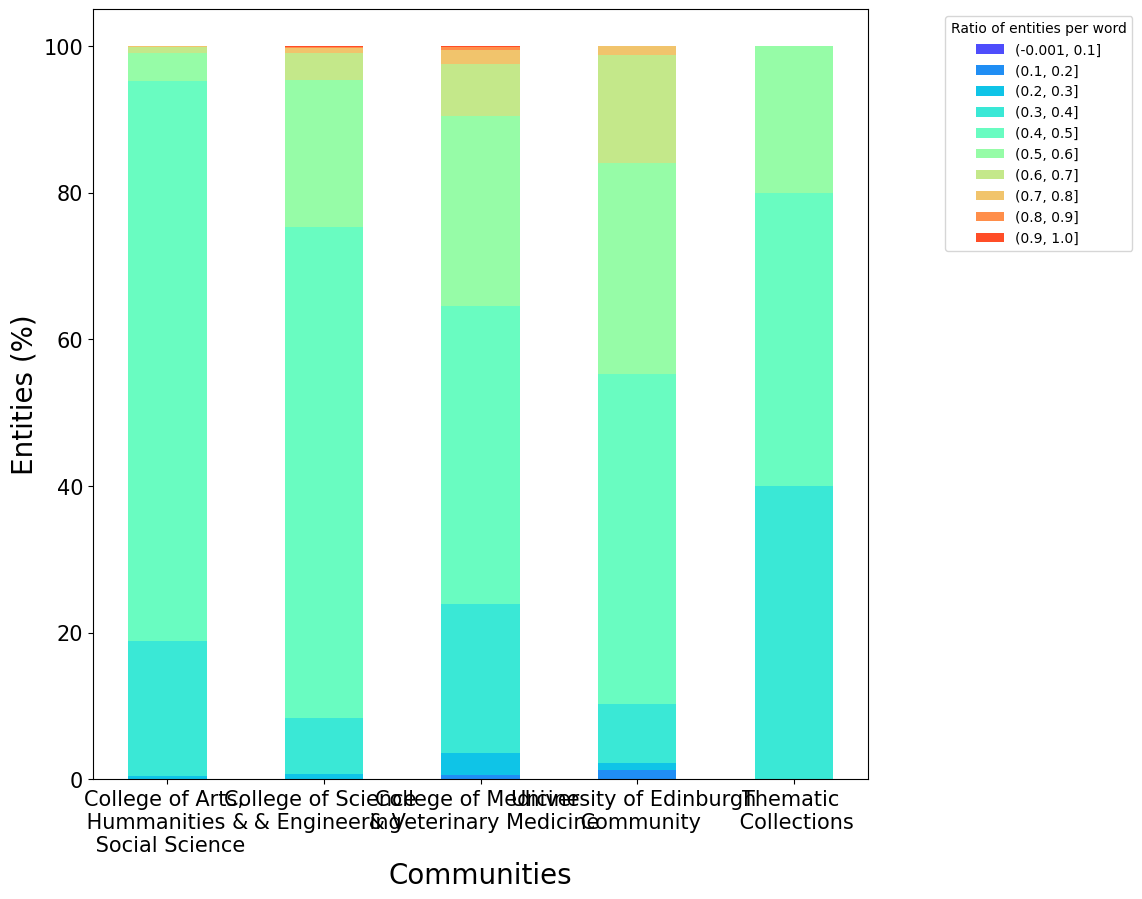

In [130]:
from matplotlib import cm

colors = ['mignightblue','darkslateblue','blue','green', 'yellow','orange', 'red', 'darkblue', 'darkgreen', 'darkorange'] 
palette = cm.rainbow(np.linspace(0.1, 0.9, 10))

plt.subplots(figsize = (10,10))
bar_width = 0.5
index = np.arange(len(communities))

data = np.array(data)
bottom = np.zeros(len(communities))

for i in range(len(values)):
    plt.bar(index, data[:, i], bar_width, bottom = bottom, color = palette[i % len(palette)], label = values[i])
    bottom += data[:,i]


plt.xlabel('Communities', fontsize = 20)
plt.ylabel('Entities (%)', fontsize = 20)

#plt.title('Percentage of the ratio of entities in the abstracts per community')
plt.xticks(index, communities, fontsize = 15)
plt.yticks(fontsize = 15)

plt.legend(title = 'Ratio of entities per word', bbox_to_anchor = (1.35, 1), loc = 'upper right', fontsize = 10)
#plt.tight_layout()
plt.show()

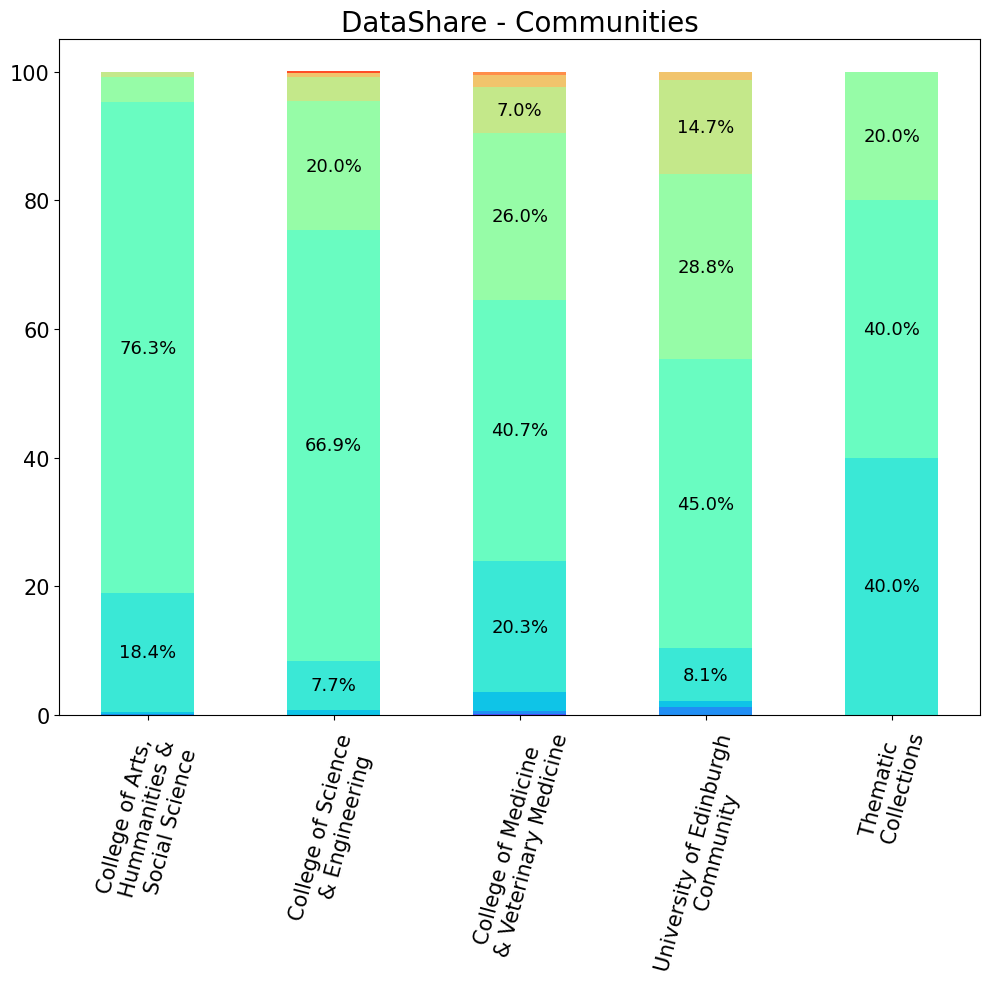

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

palette = cm.rainbow(np.linspace(0.1, 0.9, 10))

plt.figure(figsize=(10, 10))
bar_width = 0.5
index = np.arange(len(communities))

data = np.array(data)
bottom = np.zeros(len(communities))
threshold = 5

for i in range(len(values)):
    bars = plt.bar(
        index,
        data[:, i],
        bar_width,
        bottom=bottom,
        color=palette[i % len(palette)],
        label=values[i]
    )

    # Add percentage labels centered in each segment
    for j, b in enumerate(bars):
        h = b.get_height()
        if h <= threshold:
            continue

        # Only label segments large enough to read (tweak threshold as you like)
        if h < 2:   # "2" means 2 percentage points
            continue

        x = b.get_x() + b.get_width() / 2
        y = bottom[j] + h / 2
        plt.text(
            x, y,
            f"{h:.1f}%",
            ha="center", va="center",
            #rotation = 90,
            fontsize=13,
            #fontweight="bold",
            color="black"
        )

    bottom += data[:, i]

#plt.xlabel("Communities", fontsize=20)
#plt.ylabel("Entities (%)", fontsize=20)
plt.xticks(index, communities, fontsize=15, rotation=75)
plt.yticks(fontsize=15)
plt.title("DataShare - Communities", fontsize = 20)

#plt.legend(
#    title="Ratio of entities per word",
#    bbox_to_anchor=(1.35, 1),
#    loc="upper right",
#    fontsize=10
#)

plt.tight_layout()

plt.savefig("DataShare_info_density_white_spaces_20260430.png", dpi=300, bbox_inches="tight")
plt.savefig("DataShare_info_density_white_spaces_20260430.eps", dpi=300, bbox_inches="tight", format="eps")
plt.savefig("DataShare_info_density_white_spaces_20260430.pdf", dpi=300, bbox_inches="tight")

plt.show()


### Stats

In [37]:
from scipy.stats import kruskal

In [138]:
#g_arts = df_arts['ratio_entities_per_word'].to_list()
#g_medicine = df_medicine['ratio_entities_per_word'].to_list()
#g_science = df_science['ratio_entities_per_word'].to_list()
#g_support = df_support['ratio_entities_per_word'].to_list()
#g_thematic = df_thematic['ratio_entities_per_word'].to_list()

In [142]:
g_arts = df_arts['ratio_entities_per_word_with_spaces'].to_list()
g_medicine = df_medicine['ratio_entities_per_word_with_spaces'].to_list()
g_science = df_science['ratio_entities_per_word_with_spaces'].to_list()
g_support = df_support['ratio_entities_per_word_with_spaces'].to_list()
g_thematic = df_thematic['ratio_entities_per_word_with_spaces'].to_list()

In [133]:
g_support

[0.4715261958997722,
 0.6,
 0.4742014742014742,
 0.5049019607843137,
 0.46384039900249374,
 0.6842105263157895,
 0.52,
 0.5087719298245614,
 0.42857142857142855,
 0.5616438356164384,
 0.36220472440944884,
 0.40512820512820513,
 0.5454545454545454,
 0.6206896551724138,
 0.16129032258064516,
 0.5185185185185185,
 0.46808510638297873,
 0.46153846153846156,
 0.4742014742014742,
 0.47619047619047616,
 0.6333333333333333,
 0.6875,
 0.5121951219512195,
 0.4647887323943662,
 0.5897435897435898,
 0.4264705882352941,
 0.6756756756756757,
 0.6,
 0.5179153094462541,
 0.5,
 0.41509433962264153,
 0.5040983606557377,
 0.49122807017543857,
 0.6216216216216216,
 0.16666666666666666,
 0.42105263157894735,
 0.4918032786885246,
 0.4742014742014742,
 0.4222222222222222,
 0.48936170212765956,
 0.5471698113207547,
 0.5818181818181818,
 0.4444444444444444,
 0.46875,
 0.5370370370370371,
 0.5806451612903226,
 0.5806451612903226,
 0.4619883040935672,
 0.4827586206896552,
 0.52,
 0.44086021505376344,
 0.62068965

In [127]:
for i, g in enumerate(groups, 1):
    a = np.asarray(g, dtype=float)
    print(
        f"g{i}: n={a.size}, "
        f"NaN={np.isnan(a).sum()}, "
        f"inf={np.isinf(a).sum()}, "
        f"unique={np.unique(a[~np.isnan(a) & ~np.isinf(a)]).size}"
    )

g1: n=4254, NaN=3, inf=0, unique=652
g2: n=1706, NaN=6, inf=0, unique=372
g3: n=1045, NaN=32, inf=0, unique=467
g4: n=320, NaN=0, inf=0, unique=193
g5: n=7, NaN=2, inf=0, unique=3


#### Anova

In [137]:
import numpy as np
from scipy import stats

groups = [g_arts, g_medicine, g_science, g_support]

# Remove NaNs (and also drop inf just in case)
clean = []
for g in groups:
    g = np.asarray(g, dtype=float)
    g = g[np.isfinite(g)]          # removes NaN and +/-inf
    clean.append(g)

# Check sizes after cleaning
print([len(g) for g in clean])

F, p = stats.f_oneway(*clean)

print("F =", F, "p =", p)

[4251, 1700, 1013, 320]
F = 351.46320508977436 p = 3.648529413529176e-213


In [143]:
import numpy as np
import pandas as pd

# g1..g5 are your arrays/lists
groups = [g_arts, g_medicine, g_science, g_support]
names  = ["Arts", "Medicine", "Science", "Support"]

# Clean NaN/inf and build long-format dataframe
vals_list = []
grp_list  = []

for name, g in zip(names, groups):
    g = np.asarray(g, dtype=float)
    g = g[np.isfinite(g)]  # removes NaN and +/-inf
    vals_list.append(g)
    grp_list.append(np.repeat(name, len(g)))

values = np.concatenate(vals_list)
labels = np.concatenate(grp_list)

df = pd.DataFrame({"value": values, "group": labels})
df.groupby("group").size()


group
Arts        4251
Medicine    1700
Science     1013
Support      320
dtype: int64

#### Tukey HSD

In [144]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tuk = pairwise_tukeyhsd(endog=df["value"], groups=df["group"], alpha=0.05)
print(tuk)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower  upper  reject
------------------------------------------------------
    Arts Medicine   0.0417    0.0  0.037 0.0465   True
    Arts  Science   0.0488    0.0  0.043 0.0546   True
    Arts  Support   0.0764    0.0 0.0668  0.086   True
Medicine  Science    0.007 0.0296 0.0005 0.0136   True
Medicine  Support   0.0347    0.0 0.0246 0.0448   True
 Science  Support   0.0276    0.0  0.017 0.0382   True
------------------------------------------------------


In [145]:
print(tuk) 

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj  lower  upper  reject
------------------------------------------------------
    Arts Medicine   0.0417    0.0  0.037 0.0465   True
    Arts  Science   0.0488    0.0  0.043 0.0546   True
    Arts  Support   0.0764    0.0 0.0668  0.086   True
Medicine  Science    0.007 0.0296 0.0005 0.0136   True
Medicine  Support   0.0347    0.0 0.0246 0.0448   True
 Science  Support   0.0276    0.0  0.017 0.0382   True
------------------------------------------------------
